<a href="https://colab.research.google.com/github/marimcmurtrie/machine_learning/blob/main/histogram_bayesian_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Mari McMurtrie

The dataset that you need is in one of the sheets of the Excel file Assignment_1_Data_and_Template.xlsx Download Assignment_1_Data_and_Template.xlsx. The other sheets contain shaded cells meant to be filled in by you. Examine the sheets carefully and understand what must be computed or described. Except for filling in your results in the specific cells provided, do not alter the spreadsheet in any other way. This is the only recognized means of submitting this assignment.

Construct separate histograms for male and female heights using 32 bins. Remember that the histograms are lists of 32 counts that you enter into the correct cells in the spreadsheet. They are not just pretty pictures!
Based on the histograms, compute the class label (male or female) and the corresponding posterior probability of individuals with heights 55, 60, 65, 70, 75 and 80 inches
Find the parameters of Gaussian models for the 2 PDFs to describe the data. You may use built-in functions to compute the model parameters.

Use the Bayesian Formula with the model parameters found above to re-compute the class label (gender) and the corresponding posterior probability of individuals with heights 55, 60, 65, 70, 75 and 80 inches.
Repeat steps 2 through 5 using just the first 50 height entries in the data file. Now, what are your observations regarding histogram classifiers and Bayesian classifiers?

My approaches

1: Read excel sheet into memory
2: For each row
- compute inches from feet/inch
- store it in female and male array
3: I have 2 numpy arrays in memory
4: Constract histgram of 32 bins.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
height_gender_xls = pd.ExcelFile('Assignment_1_Data_and_Template.xlsx')
df = pd.read_excel(height_gender_xls, "Data")
df

,Height_Feet,Height_Inches,Gender
0,5,10,Male
1,6,4,Male
2,5,10,Male
3,5,9,Male
4,5,7,Female
...,...,...,...
16695,5,6,Female
16696,5,5,Female
16697,5,9,Male
16698,5,0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16700 entries, 0 to 16699
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Height_Feet    16700 non-null  int64 
 1   Height_Inches  16700 non-null  int64 
 2   Gender         16700 non-null  object
dtypes: int64(2), object(1)
memory usage: 391.5+ KB


In [ ]:
def get_heights(df):
    female_heights = []
    male_heights = []
    min_height = 10000
    max_height = -1
    for index, row in df.iterrows():
        inches = row["Height_Feet"] * 12 + row["Height_Inches"]
        if inches < min_height:
            min_height = inches
        if inches > max_height:
            max_height = inches

        if row["Gender"] == "Female":
            female_heights.append(inches)
        else:
            male_heights.append(inches)
    print(f"Number of females: {len(female_heights)}")
    print(f"Number of males: {len(male_heights)}")
    print(f"Min height: {min_height}")
    print(f"Max height: {max_height}")
    return female_heights, male_heights, min_height, max_height

female_heights, male_heights, min_height, max_height = get_heights(df)

Number of females: 8900
Number of males: 7800
Min height: 52
Mac height: 83


In [ ]:
female = np.array(female_heights)
male = np.array(male_heights)
female

array([67, 69, 65, ..., 65, 60, 64])

In [ ]:
# Missed - I should calculate range for histgram for better display
bar_width = (max_height - min_height) / (32-1)
bar_width

1.0

In [ ]:
female_hg = np.histogram(female, bins=32, range=(min_height - bar_width/2, max_height + bar_width/2))
male_hg = np.histogram(male, bins=32, range=(min_height - bar_width/2, max_height + bar_width/2))
print(female_hg[0])
print(female_hg[1])
print("======================")
print(male_hg[0])
print(male_hg[1])
# Note: bin is the same for both genders

[   3    5   12   24   44  101  163  260  404  549  693  869 1076 1013
  951  823  695  494  299  217  110   58   20   12    5    0    0    0
    0    0    0    0]
[51.5 52.5 53.5 54.5 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5
 65.5 66.5 67.5 68.5 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5
 79.5 80.5 81.5 82.5 83.5]
[  0   0   0   0   0   0   0   0   1  10  14  53 117 241 369 500 700 787
 849 882 873 779 610 432 274 155  83  38  24   5   3   1]
[51.5 52.5 53.5 54.5 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5
 65.5 66.5 67.5 68.5 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5
 79.5 80.5 81.5 82.5 83.5]


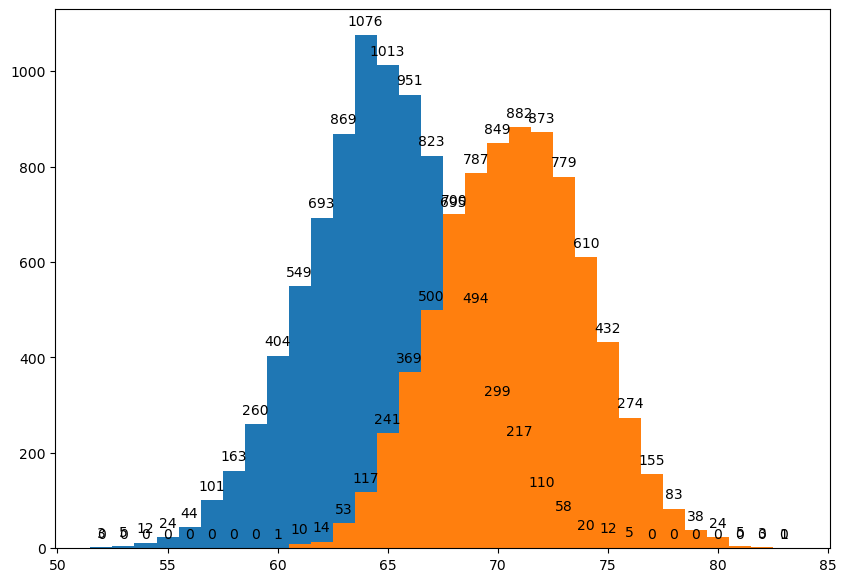

In [ ]:
def draw_histogram(female, male, bins):
    fig, ax = plt.subplots(figsize=(10, 7))

    ax.hist(female, bins=bins)
    ax.hist(male, bins=bins)

    for rect in ax.patches:
        height = rect.get_height()
        ax.annotate(f'{int(height)}', xy=(rect.get_x()+rect.get_width()/2, height),
                    xytext=(0, 5), textcoords='offset points', ha='center', va='bottom')

    plt.show()

draw_histogram(female, male, female_hg[1])

### Now, I have to compute the class label (male or female) and the corresponding posterior probability of individuals with heights 55, 60, 65, 70, 75 and 80 inches.

55: Female:24, Male:0
60: Female:404, Male:1
65: Female:1013, Male:241
70: Female:299, Male:849
75: Female:12, Male:432
80: Female:0, Male:24

In [ ]:
# Manually collected from above histgram
# Teacher's example collect this by code
female_counts = np.array([24, 404, 1013, 299, 12, 0])
male_counts = np.array([0, 1, 241, 849, 432, 24])
print("How many people in each 55, 60, 65, 70, 75 and 80 inches")
print(f"{female_counts = }")
print(f"{male_counts = }")

How many people in each 55, 60, 65, 70, 75 and 80 inches
female_counts = array([  24,  404, 1013,  299,   12,    0])
male_counts = array([  0,   1, 241, 849, 432,  24])


In [ ]:
# Probability formula for Female - F/(F+M)
# Probability formula for Male - M/(F+M)
probability_female = female_counts / (female_counts + male_counts)
probability_male = male_counts / (female_counts + male_counts)
print("Probability of male/female in each 55, 60, 65, 70, 75 and 80 inches")
print(f"{probability_female = }")
print(f"{probability_male = }")  # Male probability is (1 - female)

Probability of male/female in each 55, 60, 65, 70, 75 and 80 inches
probability_female = array([1.        , 0.99753086, 0.80781499, 0.26045296, 0.02702703,
       0.        ])
probability_male = array([0.        , 0.00246914, 0.19218501, 0.73954704, 0.97297297,
       1.        ])


In [ ]:
# Now, given a height X, is the person likely male or female?
likely_gender_at_height = ["Female" if pf > 0.5 else "Male" for pf in probability_female]
print("How likely the person's gender at given height in each 55, 60, 65, 70, 75 and 80 inches")
print(likely_gender_at_height)

How likely the person's gender at given height in each 55, 60, 65, 70, 75 and 80 inches
['Female', 'Female', 'Female', 'Male', 'Male', 'Male']


## Bayesian classifier

In [ ]:
# Total numbers of each class
total_female = len(female_heights)
total_male = len(male_heights)
print(f"{total_female = }")
print(f"{total_male = }")

total_female = 8900
total_male = 7800


In [ ]:
# Mean of each gender's height
mean_female = np.mean(female)
mean_male = np.mean(male)
print(f"{mean_female = }")
print(f"{mean_male = }")

mean_female = 64.72573033707866
mean_male = 70.76807692307692


In [ ]:
# standard diviation
std_female = np.std(female)
std_male = np.std(male)
print(f"{std_female = }")
print(f"{std_male = }")

std_female = 3.478239057126158
std_male = 3.3094552025480843


In [ ]:
#Define the Gaussian Probability Density function (PDF)
def gauss(df_query, mean, stdv):
    factor = 1/(np.sqrt(2*np.pi)*stdv)
    return factor*np.exp(-0.5*((df_query-mean)/stdv)**2)

In [ ]:
# Get hights as dataframe
heights = pd.read_excel('Assignment_1_Data_and_Template.xlsx', sheet_name='Queries', header=1, usecols=['Query (inches)'], nrows=6)['Query (inches)']
heights

0    55
1    60
2    65
3    70
4    75
5    80
Name: Query (inches), dtype: int64

In [ ]:
# Estimate Counts of Male and Female at given hights
# I have this from above: bar_width = (max_height - min_height) / (32-1)
estimate_counts_female_at_given_height = total_female * bar_width * gauss(heights, mean_female, std_female)
estimate_counts_male_at_given_height = total_male * bar_width * gauss(heights, mean_male, std_male)

print(f"estimate_counts_female_at_given_height\n{estimate_counts_female_at_given_height}\n\n")
print(f"estimate_counts_male_at_given_height\n{estimate_counts_male_at_given_height}")

estimate_counts_female_at_given_height
0      20.472295
1     405.600556
2    1017.631325
3     323.327248
4      13.009304
5       0.066287
Name: Query (inches), dtype: float64


estimate_counts_male_at_given_height
0      0.011061
1      4.724559
2    205.879744
3    915.275424
4    415.122076
5     19.208157
Name: Query (inches), dtype: float64


In [ ]:
# Posterior probabilities = (estimate_count_of_class)/(sum of estimated_counts of all classes)
sum_all_class = estimate_counts_female_at_given_height + estimate_counts_male_at_given_height
posterior_probablities_female = estimate_counts_female_at_given_height / sum_all_class
posterior_probablities_male = estimate_counts_male_at_given_height / sum_all_class

print(f"{posterior_probablities_female = }")
print(f"{posterior_probablities_male = }")

posterior_probablities_female = 0    0.999460
1    0.988486
2    0.831730
3    0.261042
4    0.030386
5    0.003439
Name: Query (inches), dtype: float64
posterior_probablities_male = 0    0.000540
1    0.011514
2    0.168270
3    0.738958
4    0.969614
5    0.996561
Name: Query (inches), dtype: float64


## Now, I do the same for the 1st 50 rows...


In [ ]:
# I do have an entire data here
df_50 = df.head(50)
#df_50
female_heights_50, male_heights_50, min_height_50, max_height_50 = get_heights(df_50)

Number of females: 28
Number of males: 22
Min height: 55
Mac height: 80


In [ ]:
female_50 = np.array(female_heights_50)
male_50 = np.array(male_heights_50)

# For comparison to the full set, we want a range to be the same. Set min/max to the same as full set.
min_height_50 = min_height
max_height_50 = max_height

bar_widths_50 = (max_height_50 - min_height_50) / (32-1)
bar_widths_50

1.0

In [ ]:
female_hg_50 = np.histogram(female_50, bins=32, range=(min_height_50 - bar_widths_50/2, max_height_50 + bar_widths_50/2))
male_hg_50 = np.histogram(male_50, bins=32, range=(min_height_50 - bar_widths_50/2, max_height_50 + bar_widths_50/2))
print(female_hg_50[0])
print(female_hg_50[1])
print("======================")
print(male_hg_50[0])
print(male_hg_50[1])

[0 0 0 1 1 0 1 1 0 1 4 2 4 3 3 1 1 4 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
[51.5 52.5 53.5 54.5 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5
 65.5 66.5 67.5 68.5 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5
 79.5 80.5 81.5 82.5 83.5]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 0 2 3 3 2 1 4 1 2 0 0 0 1 0 0 0]
[51.5 52.5 53.5 54.5 55.5 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5
 65.5 66.5 67.5 68.5 69.5 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5
 79.5 80.5 81.5 82.5 83.5]


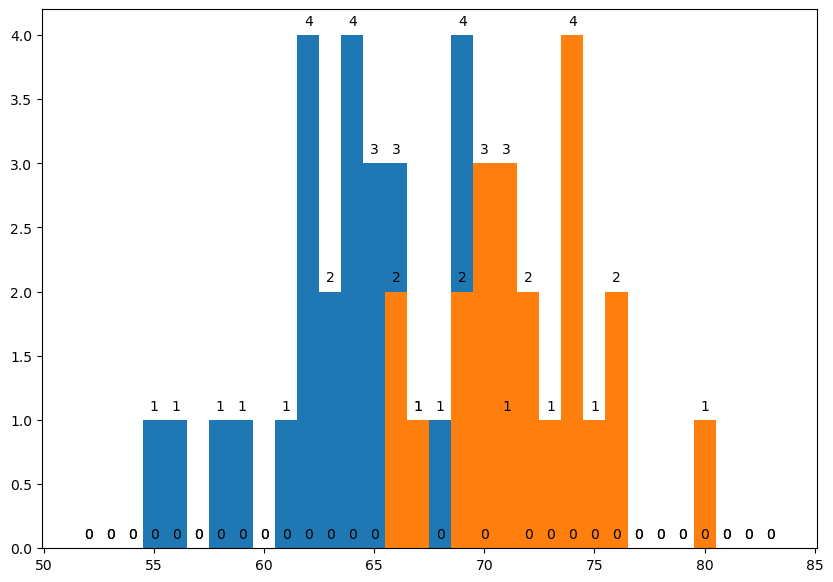

In [ ]:
draw_histogram(female_50, male_50, female_hg_50[1])

In [ ]:
# We collect count of people at each height.
bin_indices_at_queries = np.digitize(np.clip(heights, min_height_50, max_height_50), female_hg_50[1], right=False) - 1
print(f"{bin_indices_at_queries = }")

female_counts_50 = female_hg_50[0][bin_indices_at_queries]
male_counts_50 = male_hg_50[0][bin_indices_at_queries]
print(f"{female_counts_50 = }")
print(f"{male_counts_50 = }")

bin_indices_at_queries = array([ 3,  8, 13, 18, 23, 28])
female_counts_50 = array([1, 0, 3, 0, 0, 0])
male_counts_50 = array([0, 0, 0, 3, 1, 1])


In [ ]:
# Probability formula for Female - F/(F+M)
# Probability formula for Male - M/(F+M)
probability_female_50 = female_counts_50 / (female_counts_50 + male_counts_50)
probability_male_50 = male_counts_50 / (female_counts_50 + male_counts_50)
print("Probability of male/female in each 55, 60, 65, 70, 75 and 80 inches")
print(f"{probability_female_50 = }")
print(f"{probability_male_50 = }")  # Male probability is (1 - female)

Probability of male/female in each 55, 60, 65, 70, 75 and 80 inches
probability_female_50 = array([ 1., nan,  1.,  0.,  0.,  0.])
probability_male_50 = array([ 0., nan,  0.,  1.,  1.,  1.])


/var/folders/nb/p2_n69fx3dn1y4ctxr_m18yc0000gn/T/ipykernel_1914/2386404188.py:3: RuntimeWarning: invalid value encountered in divide
  probability_female_50 = female_counts_50 / (female_counts_50 + male_counts_50)
/var/folders/nb/p2_n69fx3dn1y4ctxr_m18yc0000gn/T/ipykernel_1914/2386404188.py:4: RuntimeWarning: invalid value encountered in divide
  probability_male_50 = male_counts_50 / (female_counts_50 + male_counts_50)


In [ ]:
# Now, given a height X, is the person likely male or female?
import math
likely_gender_at_height_50 = []
for pf in probability_female_50:
    if math.isnan(pf):
        likely_gender_at_height_50.append("We do not know!")
    elif pf > 0.5:
        likely_gender_at_height_50.append("Female")
    else:
        likely_gender_at_height_50.append("Male")

print("How likely the person's gender at given height in each 55, 60, 65, 70, 75 and 80 inches")
print(likely_gender_at_height_50)

How likely the person's gender at given height in each 55, 60, 65, 70, 75 and 80 inches
['Female', 'We do not know!', 'Female', 'Male', 'Male', 'Male']


## Bayesian classifier


In [ ]:
# Total numbers of each class
total_female_50 = len(female_heights_50)
total_male_50 = len(male_heights_50)

# Mean of each gender's height
mean_female_50 = np.mean(female_50)
mean_male_50 = np.mean(male_50)

# standard diviation
std_female_50 = np.std(female_50)
std_male_50 = np.std(male_50)

# Estimate Counts of Male and Female at given hights
estimate_counts_female_at_given_height_50 = total_female_50 * bar_widths_50 * gauss(heights, mean_female_50, std_female_50)
estimate_counts_male_at_given_height_50 = total_male_50 * bar_widths_50 * gauss(heights, mean_male_50, std_male_50)

print(f"{ total_female_50 = }")
print(f"{ total_male_50 = }")
print(f"{ mean_female_50 = }")
print(f"{ mean_male_50 = }")
print(f"{ std_female_50 = }")
print(f"{ std_male_50 = }")
print(f"{ estimate_counts_female_at_given_height_50 = }")
print(f"{ estimate_counts_male_at_given_height_50 = }")

 total_female_50 = 28
 total_male_50 = 22
 mean_female_50 = 64.07142857142857
 mean_male_50 = 71.81818181818181
 std_female_50 = 3.881536619769578
 std_male_50 = 3.379569144625656
 estimate_counts_female_at_given_height_50 = 0    0.187511
1    1.660164
2    2.796643
3    0.896366
4    0.054663
5    0.000634
Name: Query (inches), dtype: float64
 estimate_counts_male_at_given_height_50 = 0    0.000011
1    0.005742
2    0.339345
3    2.247094
4    1.667220
5    0.138598
Name: Query (inches), dtype: float64


In [ ]:
# Posterior probabilities = (estimate_count_of_class)/(sum of estimated_counts of all classes)
sum_all_class_50 = estimate_counts_female_at_given_height_50 + estimate_counts_male_at_given_height_50
posterior_probablities_female_50 = estimate_counts_female_at_given_height_50 / sum_all_class_50
posterior_probablities_male_50 = estimate_counts_male_at_given_height_50 / sum_all_class_50

print(f"{posterior_probablities_female_50 = }")
print(f"{posterior_probablities_male_50 = }")

posterior_probablities_female_50 = 0    0.999942
1    0.996553
2    0.891790
3    0.285153
4    0.031746
5    0.004555
Name: Query (inches), dtype: float64
posterior_probablities_male_50 = 0    0.000058
1    0.003447
2    0.108210
3    0.714847
4    0.968254
5    0.995445
Name: Query (inches), dtype: float64
